# Algoritmo Genético Simple — Ejercicio

**Función objetivo:**
$$f(x) = 1 - \frac{11}{2}\left(x - \frac{7}{2}\right)^2 \cos\left(\frac{11}{2}\left(x - \frac{7}{2}\right)\right) + 1 + 2$$

**Dominio:** $x \in [0,\ 0.875]$

## 1. Importar librerías

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Parámetros del AGS

In [10]:
Nind   = 5        # Tamaño de la población
Lind   = 10       # Bits por individuo
Pc     = 0.70     # Probabilidad de cruza
Pm     = 1/15     # Probabilidad de mutación
Maxgen = 100      # Número de generaciones
Nvar   = 1
rango  = np.array([[0, 0.875]])  # shape (Nvar, 2): cada fila = [min, max]

## 3. Funciones del AGS
> Las mismas del ejemplo resuelto. Solo cambia `decodifica` (distinta convención de `rango` para 1 variable) y `objfun`.

In [11]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

In [12]:
def decodifica(genotipo, rango):
    """rango shape (Nvar, 2): rango[j] = [min_j, max_j]"""
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))
    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j*Lvar):(j*Lvar+Lvar)])
    for j in range(Nvar):
        fenotipo[:, j] = rango[j,0] + ((rango[j,1] - rango[j,0]) / (2**Lvar - 1)) * fenotipo[:, j]
    return fenotipo

In [13]:
def objfun(fenotipo):
    """Función objetivo del ejercicio."""
    Nind, _ = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        x = fenotipo[i, 0]
        term = (11/2) * (x - 7/2)**2
        objv[i, 0] = 1 - term * np.cos(term) + 1 + 2
    return objv

In [14]:
def rankeo(objv, direccion):
    SP = 2
    Nind = objv.shape[0]
    aptitud = np.zeros((Nind, 1))
    if direccion == 1:
        sorted_idx = np.argsort(objv[:, 0])
    else:
        sorted_idx = np.argsort(-objv[:, 0])
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    aptitud[sorted_idx, 0] = apt
    return aptitud

def ruleta(genotipo, fenotipo, aptitud):
    Nind = aptitud.shape[0]
    acumulada = np.cumsum(aptitud / np.sum(aptitud))
    idx = np.zeros(Nind, dtype=int)
    for i in range(Nind):
        aux = np.where(acumulada >= np.random.rand())[0]
        idx[i] = aux[0]
    return genotipo[idx, :]

def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :]   = np.concatenate((nuevo_gen[i, :corte],   nuevo_gen[i+1, corte:]))
            aux_gen[i+1, :] = np.concatenate((nuevo_gen[i+1, :corte], nuevo_gen[i,   corte:]))
    return aux_gen

def muta(nuevo_gen, Pm):
    mascara = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

## 4. Algoritmo Principal

In [15]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv     = objfun(fenotipo)

Mejor           = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

generaciones = 1
while generaciones < Maxgen:
    aptitud    = rankeo(objv, 1)
    nuevo_gen  = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen  = xunpunto(nuevo_gen, Pc)
    nuevo_gen  = muta(nuevo_gen, Pm)
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)
    genotipo, objv = nuevo_gen, nuevo_objv

    idx = np.argmax(objv)
    Mejor[generaciones]              = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

idx_final  = np.nanargmax(Mejor)
mejor_val  = Mejor[idx_final][0]
mejor_feno = decodifica(Mejor_cromosoma[idx_final].reshape(1, -1), rango)

print(f"Mejor f(x) = {mejor_val:.6f}")
print(f"x          = {mejor_feno[0,0]:.6f}")
print(f"Generación = {idx_final}")

Mejor f(x) = 69.792155
x          = 0.034213
Generación = 98


## 5. Gráficas

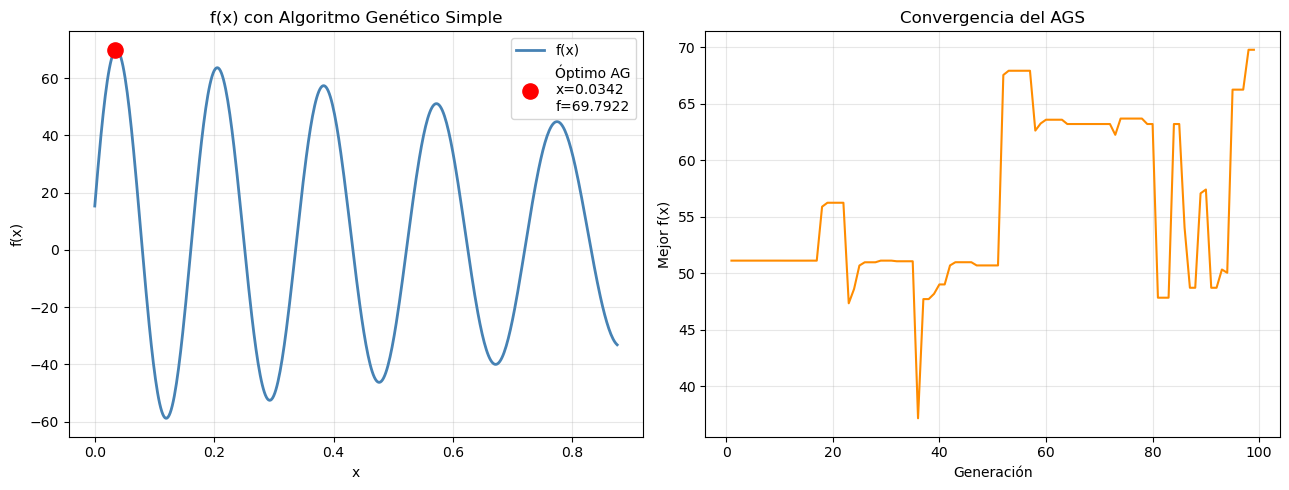

In [16]:
def f_real(x):
    term = (11/2) * (x - 7/2)**2
    return 1 - term * np.cos(term) + 1 + 2

x_plot = np.linspace(0, 0.875, 500)
y_plot = f_real(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_plot, y_plot, color='steelblue', linewidth=2, label='f(x)')
axes[0].scatter(mejor_feno[0,0], mejor_val, color='red', zorder=5, s=120,
                label=f'Óptimo AG\nx={mejor_feno[0,0]:.4f}\nf={mejor_val:.4f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title('f(x) con Algoritmo Genético Simple')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

gen_v = np.where(~np.isnan(Mejor[:,0]))[0]
axes[1].plot(gen_v, Mejor[gen_v, 0], color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Generación'); axes[1].set_ylabel('Mejor f(x)')
axes[1].set_title('Convergencia del AGS')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()